---
## Part A: Conceptual Understanding (Theory)


**Q1. What are Supervised Learning Algorithms?**  
Supervised learning algorithms learn from labelled data — input features (X) paired with known output values (y). The model learns the mapping `f(X) → y` and uses that mapping to predict outputs on new, unseen data. Examples: Linear Regression, Decision Trees, SVMs.

---

**Q2. Difference between Regression and Classification Algorithms**  
- **Regression** predicts a **continuous numeric** output (e.g., house price = ₹3,20,00,000).  
- **Classification** predicts a **discrete category** (e.g., house type = 'villa' vs 'apartment').  
Key difference: regression measures error in real numbers (MSE, RMSE); classification measures error in probability / category correctness (accuracy, F1).

---

**Q3. Simple Linear Regression**  
Models the relationship between **one** independent variable (X) and a continuous dependent variable (y) as a straight line:  
`y = β₀ + β₁·X + ε`  
- `β₀` = intercept (y-value when X=0)  
- `β₁` = slope (change in y per unit change in X)  
- `ε` = error term (irreducible noise)

---

**Q4. Assumptions of Linear Regression**  
1. **Linearity** — relationship between X and y is linear.  
2. **Independence** — observations are not correlated with each other.  
3. **Homoscedasticity** — residuals have constant variance across all fitted values.  
4. **Normality of residuals** — errors are normally distributed.  
5. **No multicollinearity** (for MLR) — features should not be highly correlated with each other.

---

**Q5. Bias-Variance Trade-Off**  
Total prediction error = Bias² + Variance + Irreducible noise.  
- **High Bias** → model is too simple, underfits (misses real patterns).  
- **High Variance** → model is too complex, overfits (memorises noise).  
Goal: find model complexity where both are balanced for best generalisation.

---

**Q6. Overfitting and Underfitting**  
- **Underfitting**: Model is too simple. Training error is high, test error is also high. Example: using degree-1 polynomial on non-linear data.  
- **Overfitting**: Model is too complex. Training error is very low, but test error is high because the model learned the noise. Example: degree-10 polynomial on 20 data points.

---
## Part B: Dataset Understanding & Preparation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("RealEstate_HousePrice_Dataset_4200.csv")
display(df.head())
print(df.shape)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


(4200, 12)


The dataset has 4,200 houses and 11 columns. The target variable house_price_inr ranges from ₹8 lakh to ₹7.6 crore — a massive range, which tells us house prices are not uniform and several factors are driving this variation.


In [7]:
# Identify independent and dependent variables
# Not including house_id as it is just for identification not a feature or target variable 

Features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score',
            'age_years', 'distance_city_km', 'lot_size_sqft',
            'has_garage', 'has_pool', 'renovation_years_ago']

Target = 'house_price_inr'

print(f"Independent variable(X):- {Features}")
print(f"Dependent variable(Y):- {Target}")

Independent variable(X):- ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago']
Dependent variable(Y):- house_price_inr


In [9]:
# checking null values, data-types and basic statistics

print(df.isnull().sum())
print(df.dtypes)
df[Features + [Target]].describe()

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64
house_id                  int64
area_sqft                 int64
bedrooms                  int64
bathrooms                 int64
location_score          float64
age_years                 int64
distance_city_km        float64
lot_size_sqft             int64
has_garage                int64
has_pool                  int64
renovation_years_ago      int64
house_price_inr           int64
dtype: object


,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


No missing values found in any column. The data is clean and ready to use without any imputation or dropping of rows. This saves preprocessing time.

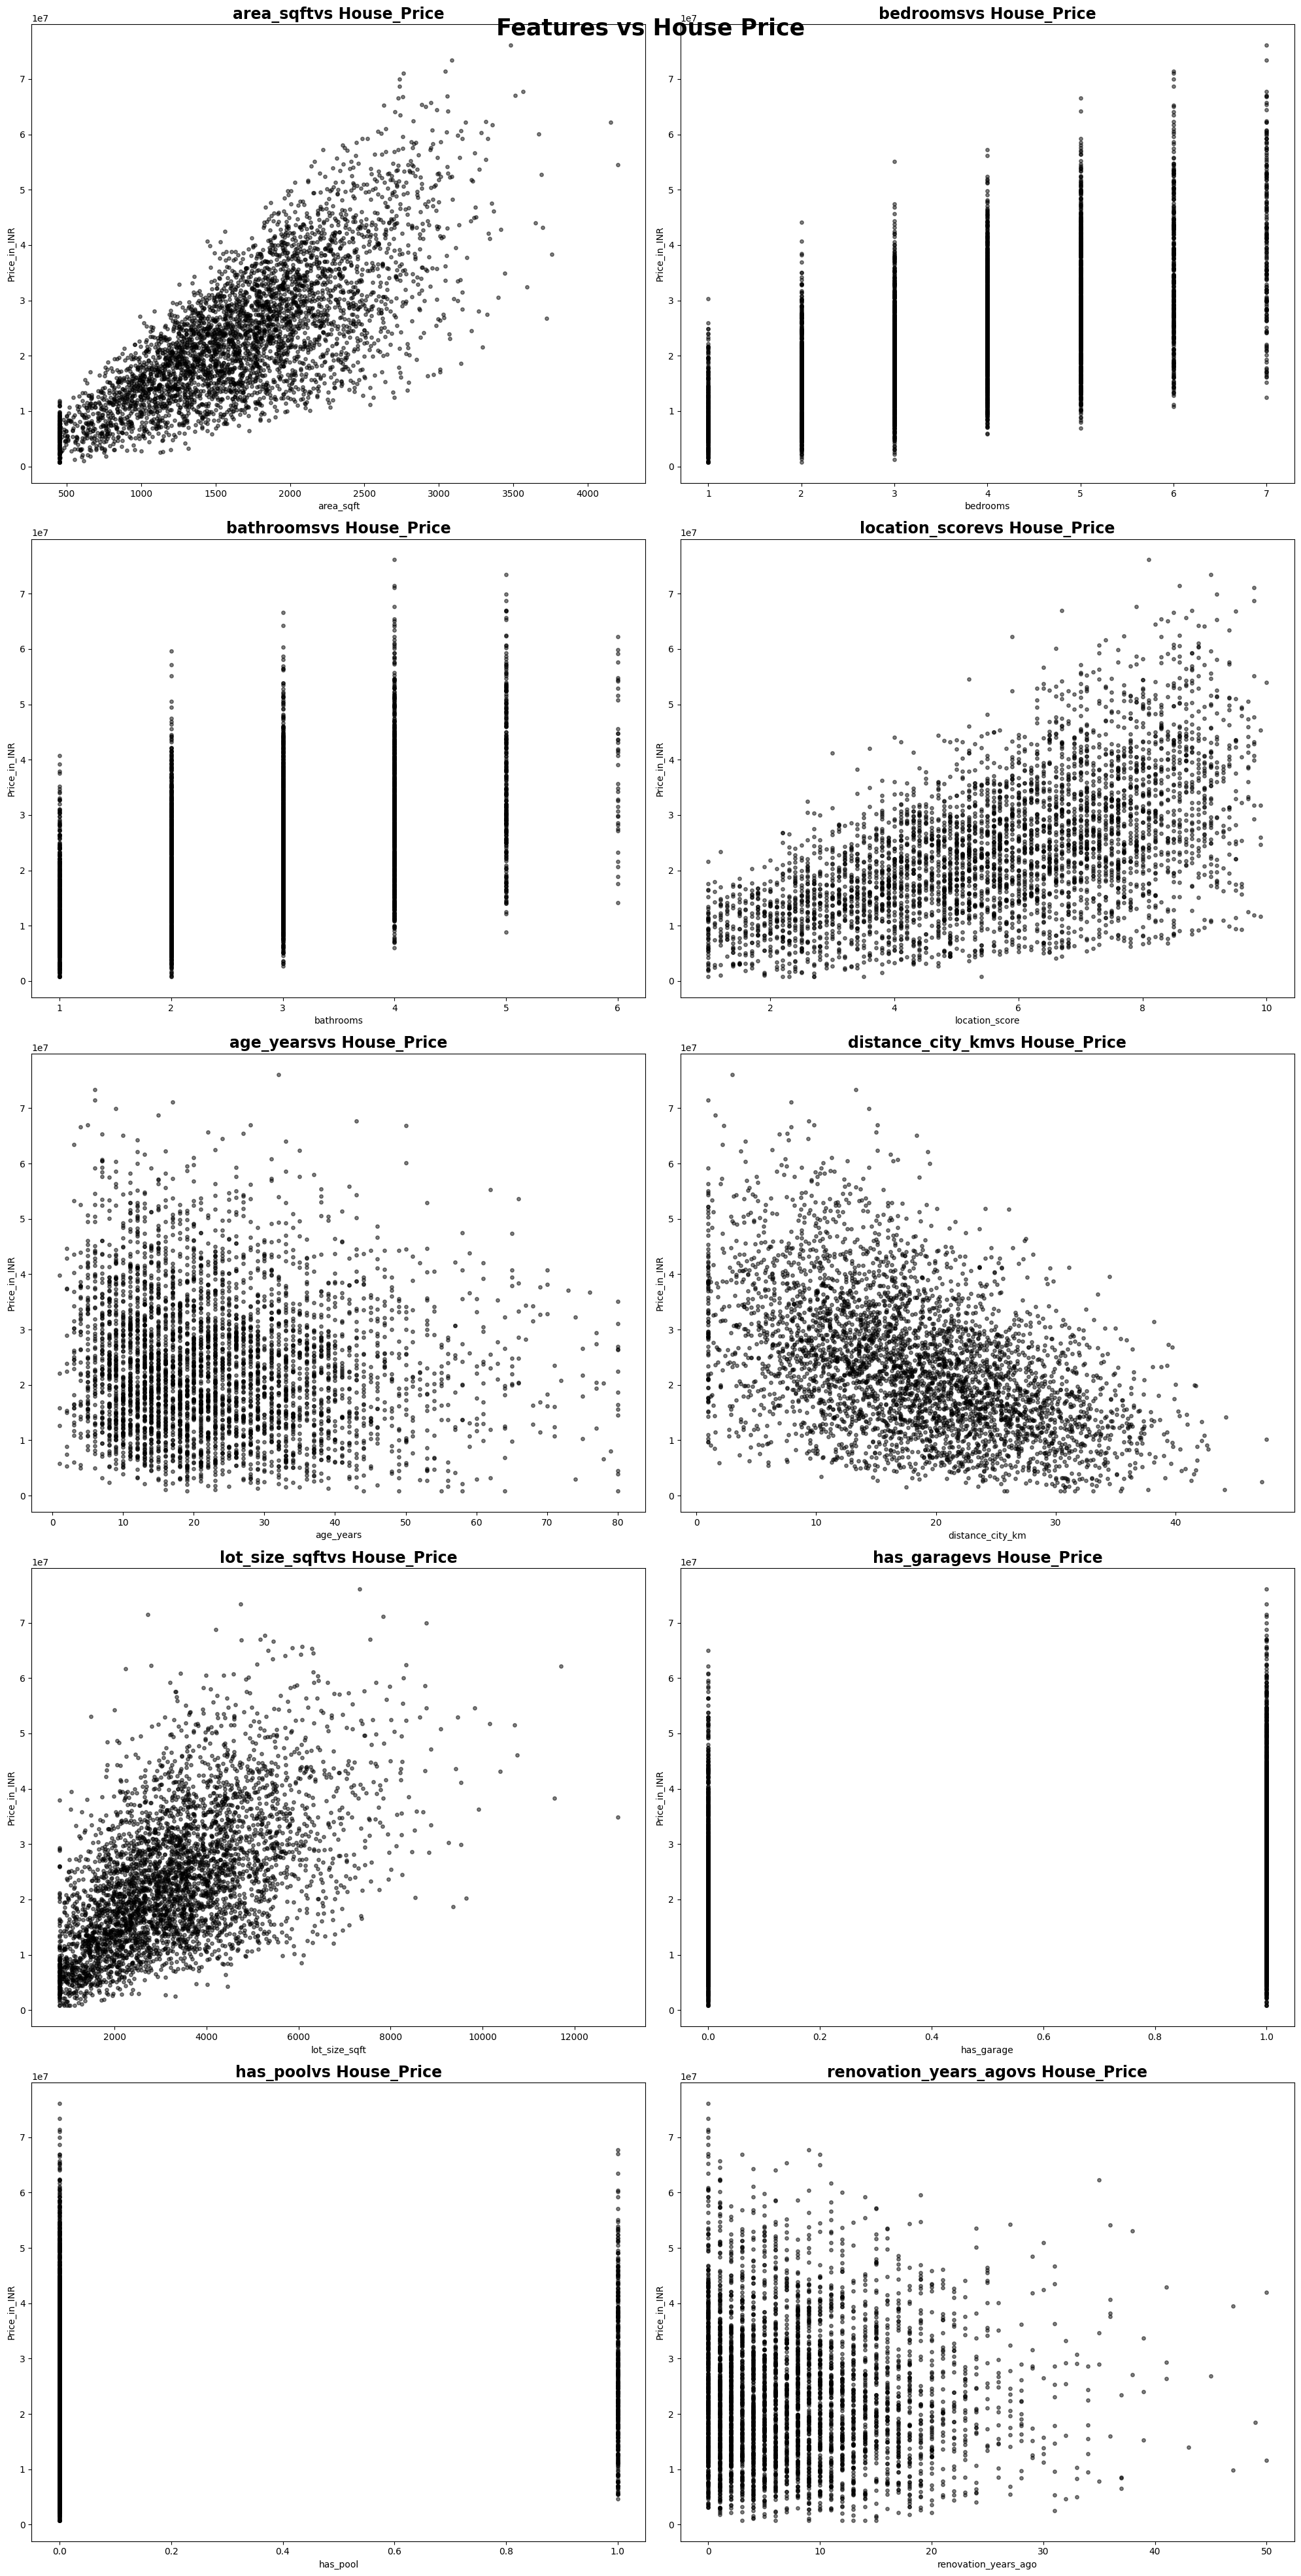

In [39]:
# Visualize relationships between features and target variables

figs, axes = plt.subplots(5,2, figsize=(20,40))
axes = axes.ravel()

for i,feature in enumerate(Features):
    axes[i].scatter(df[feature], df[Target], alpha=0.5, s=15, color="black")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price_in_INR')
    axes[i].set_title(feature + 'vs House_Price', fontweight='bold',fontsize=17)
    
plt.suptitle('Features vs House Price', fontweight='bold',fontsize=25)
plt.tight_layout()
plt.savefig("relationships between features and target variable",dpi=300)
plt.show()

area_sqft shows the clearest upward trend with price — larger houses cost more.
distance_city_km shows a clear downward trend — farther from the city means lower price. 
Features like has_garage and has_pool show less clear trends since they are binary (0 or 1).

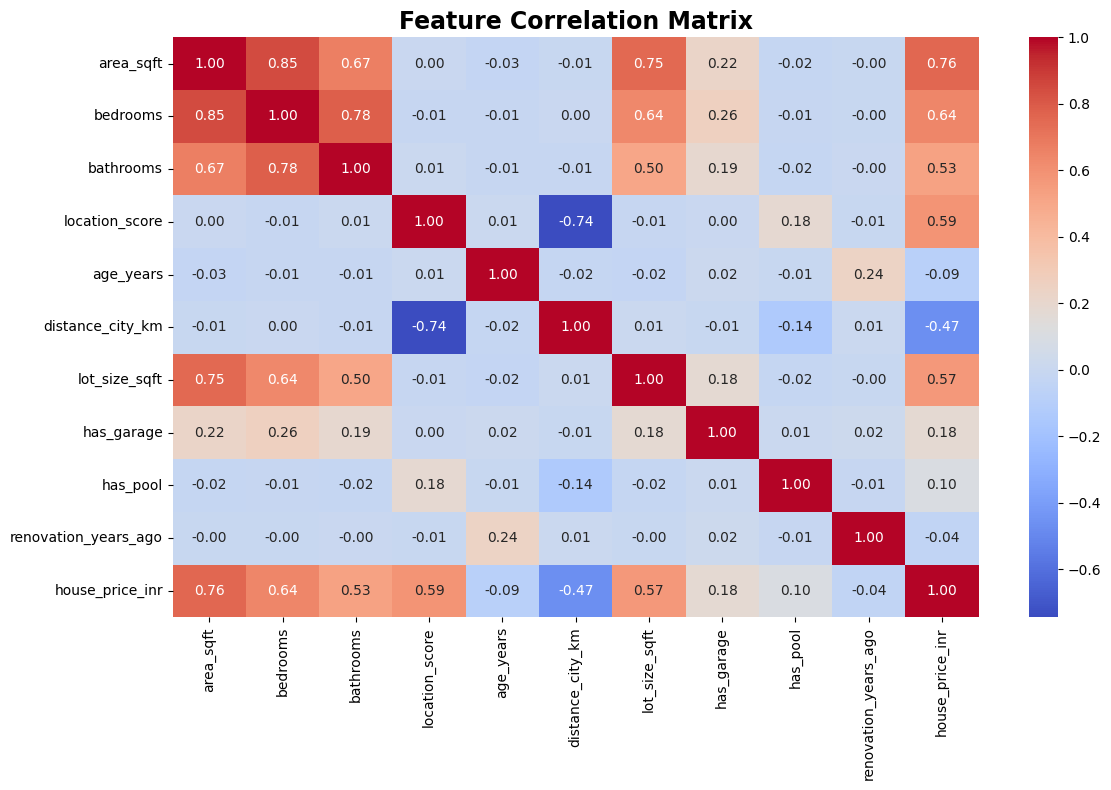

Correlation of each feature with house price:
house_price_inr         1.000000
area_sqft               0.755434
bedrooms                0.644772
location_score          0.588531
lot_size_sqft           0.567751
bathrooms               0.527044
has_garage              0.176934
has_pool                0.102015
renovation_years_ago   -0.037409
age_years              -0.089454
distance_city_km       -0.469431
Name: house_price_inr, dtype: float64


In [40]:
# correlation heatmap

plt.figure(figsize=(12, 8))
corr = df[Features + [Target]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation between features and target variable",dpi=300)

plt.show()

print('Correlation of each feature with house price:')
print(corr[Target].sort_values(ascending=False))

The three strongest positive correlations with price are:

area_sqft -> 0.75 (strongest)
bedrooms -> 0.64
location_score -> 0.59

The strongest negative correlation is distance_city_km -> -0.47, meaning farther from the city consistently means lower price. renovation_years_ago and age_years have weak negative correlations, suggesting older and less recently renovated houses lose value over time.



In [31]:
# split data into tarining and testing sets

X = df[Features]
y = df[Target]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

print('Training samples :', X_train.shape[0])
print('Testing samples  :', X_test.shape[0])

Training samples : 3360
Testing samples  : 840


3,360 samples for training, 840 for testing. This 80/20 split is standard — the model learns from training data and is evaluated on test data it has never seen, which gives a fair picture of real-world performance.

---
## Part C: Simple Linear Regression (Tasks 10–12)
Using only **area_sqft** to predict price

In [43]:
# Train Simple LinerRegression model using area_sqft only

slr = LinearRegression()
slr.fit(X_train[['area_sqft']],y_train)

slr_pred = slr.predict(X_test[['area_sqft']])

print(f'slope of the model is:- {slr.coef_}')
print(f'intercept of the model is:- {slr.intercept_}')

slope of the model is:- [14804.39324305]
intercept of the model is:- -989589.021694228


The model found a slope of ₹14,804 per sq.ft. This means for every additional square foot, the predicted house price goes up by approximately ₹14,804. The intercept is negative (₹-989589), which just means the line starts below zero — this has no real-world meaning since a 0 sq.ft house doesn't exist.

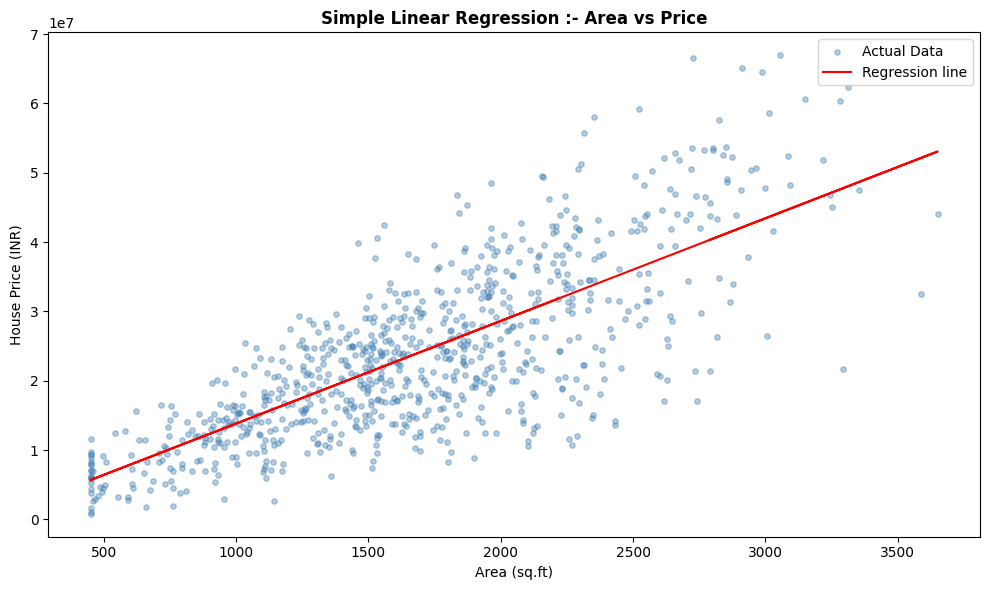

In [44]:
# Plot the regression line

plt.figure(figsize=(10, 6))
plt.scatter(X_test['area_sqft'], y_test, alpha=0.4, color='steelblue', s=15, label='Actual Data')
plt.plot(X_test['area_sqft'], slr_pred, color='red',label='Regression line')

plt.xlabel('Area (sq.ft)')
plt.ylabel('House Price (INR)')
plt.title('Simple Linear Regression :- Area vs Price', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("Regression Line ",dpi=300)

plt.show()


The red regression line captures the general upward trend well, but there is significant scatter around the line — many actual prices are far above or below the prediction. This tells us that area alone is not enough to predict price accurately. Other factors are clearly at play.

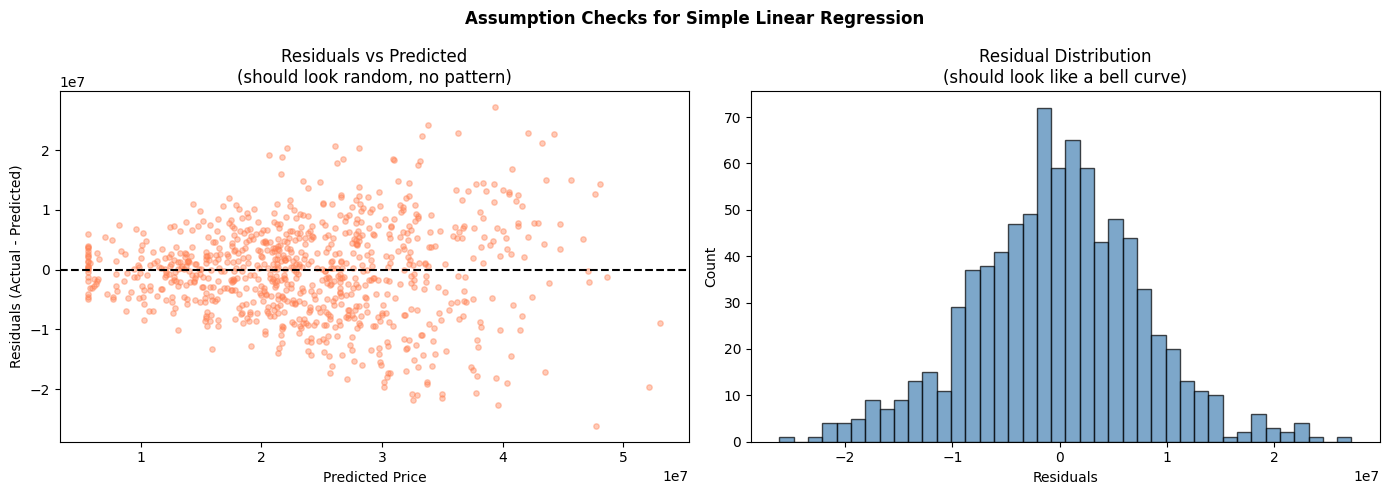

In [52]:
# validate Linear Regression Assumptions using plots and observations

residuals = y_test - slr_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(slr_pred, residuals, alpha=0.4, s=15, color='coral')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residuals vs Predicted\n(should look random, no pattern)')


axes[1].hist(residuals, bins=40, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(should look like a bell curve)')

plt.suptitle('Assumption Checks for Simple Linear Regression', fontweight='bold')
plt.tight_layout()
plt.savefig("validating linear regression assumptions",dpi=300)
plt.show()




The residuals are spread both above and below zero, and the distribution is roughly bell-shaped. However, the spread of residuals is wide — some errors are very large (₹1–2 crore off). This confirms the model is capturing the direction correctly but missing precision because it only uses one feature.